<a href="https://colab.research.google.com/github/karlaz98da/ConnectaTel-analysis/blob/main/Project_Analysis_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

El objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Se trabajara con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello se cuenta con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Este análisis  permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.


---
## 🧩 Paso 1: Cargar y explorar


### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.



In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.



In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


##✍️Resultado del análisis valores nulos


**Dataset users**

  -11% valores nulos en columna `city`, se va a **ignorar** ya que por ahora la ubicación no forma parte fundamental del análisis
  
  -88% valores nulos en columna `churn_date`, se va a **ignorar**, ya que los NA en este caso funcionan para identificar los clientes que cancelaron su servicio

  
**Dataset usage**

  -Menos del 1% valores nulos en columna `date`, se va a analizar los datos nulos para decidir si eliminar o imputar
  
  -55%  y 44% valores nulos en columna `duration` y `lenght` respectivamente, se van a conservar como nulos porque uno está relacionado con llamadas y otro con mensajes, por lo que los nulos son correctos en este caso.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
columnas_num = ["user_id", "age", ]
users[columnas_num].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



- La columna `user_id` es clasificado como numérico, pero es un identificador. No debería usarse para cálculos estadísticos.
- La columna `age` tiene valor mínimo atipico '-999', lo que puede estar afectando a la media y por eso muestra una desviación estándar alta.


In [ ]:
# explorar columnas numéricas de usage
columnas_num = ["id","user_id", "duration", "length"]
usage[columnas_num].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` son marcadas como númericas pero son identificadores. No deberían usarse para cálculos estadísticos.
- Las columnas `duration`y `length` parecen tener casos especiales donde se tienen valores máximos altos que afectan la media, pero si son posibles esos valores.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


In [ ]:
users["city"].unique()

array(['Medellín', '?', 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

- La columna `city` tiene unos valores nulos, y hay unos registros con el signo de interrogación (?). Hay 6 ciudades en el dataset y la ciudad top es Bogotá con un registro de 808 total de llamadas y mensajes.
- La columna `plan` hay dos tipos de plan: Basico y Premium, más del 50% de los usuarios cuentan con el plan Básico

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` describe si fue una llamada o un mensaje de texto el registro. Se cuentan con más registros de mensaje de texto.


##✍️Resultado del análisis

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

En el dataset **users** la columna `city`tiene que cambiar el signo de interrogación a nulos. Y la columna `age` se tiene que imputar el valor -999 por la mediana.
En el dataset **usage** no se encontraron sentinels específicos, pero si hay valores extremos que se podrían analizar después.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.



In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
print("Años únicos en reg_date:", users["reg_date"].dt.year.unique())
print("Conteo por año")
print(users["reg_date"].dt.year.value_counts().sort_index())

Años únicos en reg_date: [2022 2026 2023 2024]
Conteo por año
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, existen 40 registros de un año futuro (2026)

In [ ]:
# Revisar los años presentes en `date` de usage
print("Años únicos en date:", usage["date"].dt.year.unique())
print("Conteo por año")
print(usage["date"].dt.year.value_counts().sort_index())

Años únicos en date: [2024.   nan]
Conteo por año
2024.0    39950
Name: date, dtype: int64


En `date`, hay 50 registros que no tienen fecha
Basaremos el análisis en estas fechas.

##✍️Resultado del análisis

**Fechas fuera de rango**  

En `reg_date`las fechas futuras 2026 se recomienda marcar como nulas.
En `date` los valores nulos pueden eliminarse si se busca un análisis de patrones temporales porque sin fecha no hay forma de hacerlo.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.



In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users["city"]=users["city"].replace("?",pd.NA)

# Verificar cambios
print("Valores únicos después del cambio:")
print(users["city"].unique())
print(f"\nTotal de nulos ahora: {users['city'].isna().sum()}")

Valores únicos después del cambio:
['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Total de nulos ahora: 565


In [ ]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, pd.NaT)

# Verificar cambios
print("Años únicos en reg_date después de limpieza:")
print(users['reg_date'].dt.year.value_counts().sort_index())

Años únicos en reg_date después de limpieza:
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Analisis valores nulos
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.


In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby("type",dropna=True)["duration"].count()

type
call    17908
text       16
Name: duration, dtype: int64

In [ ]:

# Verificación MAR en usage (Missing At Random) para length
usage.groupby("type",dropna=True)["length"].count()


type
call       12
text    22092
Name: length, dtype: int64

✍️ El análisis confirma que ambos `duration`y `length` son MAR porque dependen del tipo de comunicación si son llamadas o mensajes de texto (respectivamente)

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.


In [ ]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",           # suma total de mensajes
    'is_call': 'sum',           # suma total de llamadas
    'duration': 'sum'           # suma total de minutos
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
rename_col = {"is_text":"cant_mensajes", "is_call":"cant_llamadas", "duration":"cant_minutos_llamada"}
usage_agg =usage_agg.rename(columns=rename_col)
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users,usage_agg, on="user_id", how="inner")
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2  Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.



In [ ]:
# Resumen estadístico de las columnas numéricas
col_num = ["age", "cant_mensajes","cant_llamadas","cant_minutos_llamada"]
user_profile[col_num].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.124531,5.524381,4.478120,23.317054
std,17.692032,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:

# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True) *100


Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.



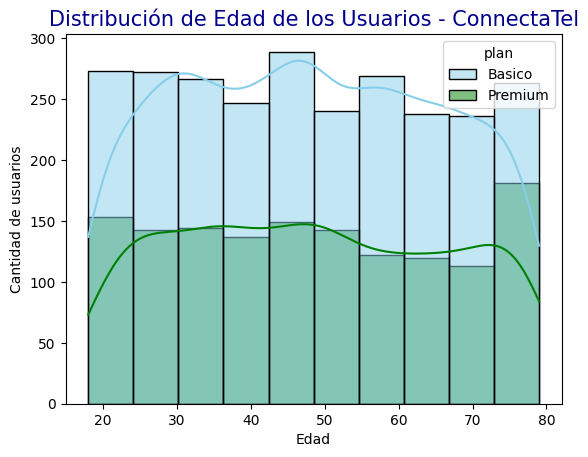

In [ ]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,x="age",bins=10, hue='plan', palette=['skyblue','green'], kde=True )
plt.title("Distribución de Edad de los Usuarios - ConnectaTel", fontsize=15, color="darkblue")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()


💡Insights:
- Distribución uniforme entre las edades de 18 y 79 años, no se tiene un sesgo de mercado entre los jovenes y adultos mayores, lo cual indica que el servicio es atractivo a todas las generaciones.
- El plan premium es preferido en las personas mayores de 75 años  

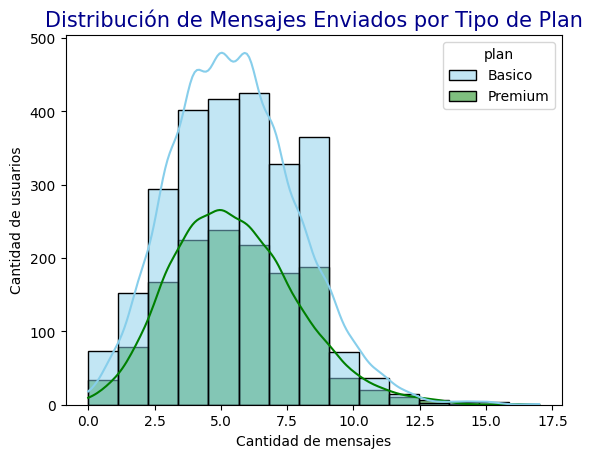

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile,x="cant_mensajes",bins=15, hue='plan', palette=['skyblue','green'], kde=True )
plt.title("Distribución de Mensajes Enviados por Tipo de Plan", fontsize=15, color="darkblue")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights:
- Tiene un ligero sesgo a la derecha ya que el 50% solo manda 5 mensajes, esto es normal debido a que normalmente se utilizan más las aplicaciones de Whatsapp a los mensajes de texto.
- Los usuarios de plan Premium son de los pocos que mandan más de 10 mensajes. Aunque aun así es muy baja la cantidad de mensajes por lo que los clientes Premium parecen adquirir el plan por otros beneficios (como minutos o datos) y no por la capacidad de mensajería.

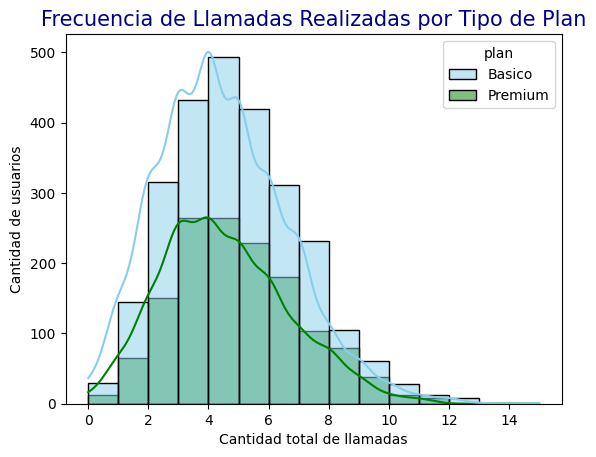

In [ ]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile,x="cant_llamadas",bins=15, hue='plan', palette=['skyblue','green'], kde=True )
plt.title("Frecuencia de Llamadas Realizadas por Tipo de Plan", fontsize=15, color="darkblue")
plt.xlabel("Cantidad total de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show(
)

💡Insights:
- Distribución ligeramente sesgada a la derecha
- Los usuarios del plan Básico tienden a realizar una cantidad moderada de llamadas, concentrándose mayoritariamente en el rango de 5 a 15 llamadas totales. No existe un patrón de uso intensivo de la línea en este segmento, lo que sugiere que utilizan el servicio para comunicaciones breves y puntuales
- Dentro del plan Premium, existe una mayor proporción de usuarios que realizan más de 20 llamadas en comparación con el plan Básico. Sin embargo, la distribución sigue la misma tendencia decreciente, lo que indica que incluso pagando más, la mayoría de los clientes no hace un uso masivo de la frecuencia de marcado.

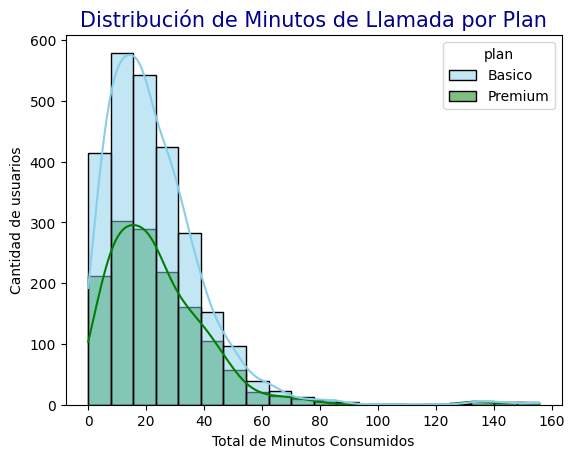

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile,x="cant_minutos_llamada",bins=20, hue='plan', palette=['skyblue','green'], kde=True )
plt.title("Distribución de Minutos de Llamada por Plan", fontsize=15, color="darkblue")
plt.xlabel("Total de Minutos Consumidos")
plt.ylabel("Cantidad de usuarios")
plt.show()


💡Insights:
- Distribución ti ene unsesgo a la derecha
- Hay un área de oportunidad con los usuarios con plan Básico que consumen más de 100 minutos por llamada.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.



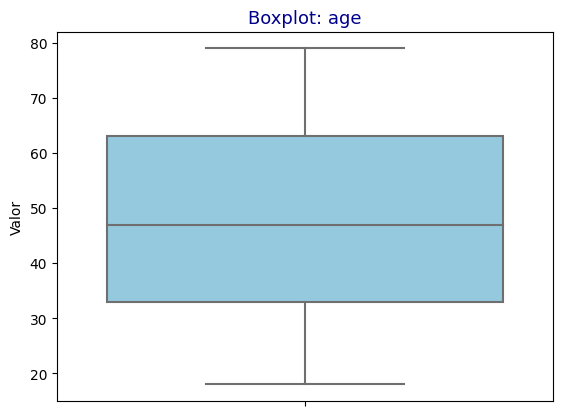

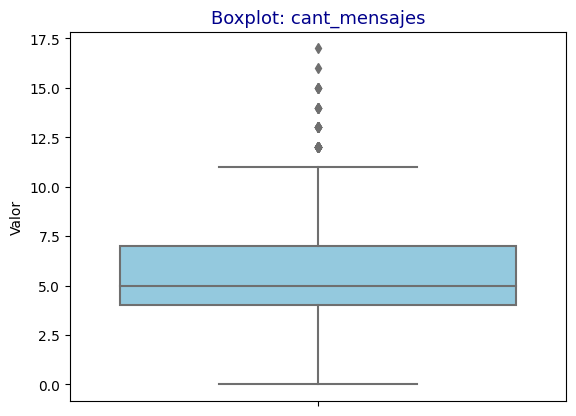

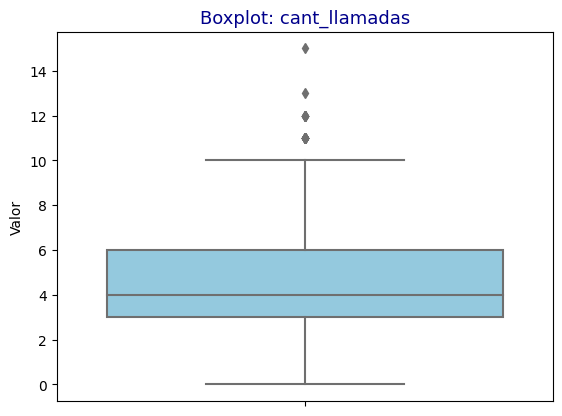

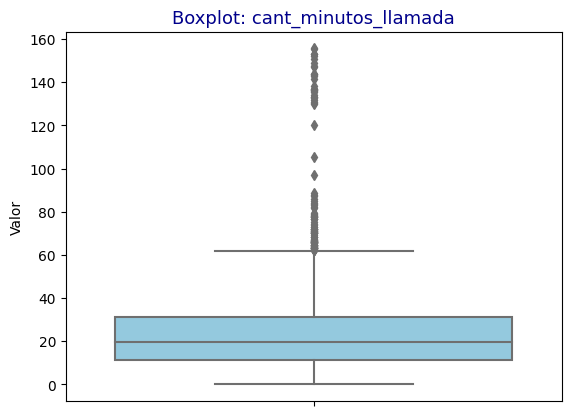

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, y=col, color= "skyblue")
    plt.title(f"Boxplot: {col}", fontsize=13, color="darkblue")
    plt.ylabel("Valor")
    plt.show()

💡Insights:
- Age: No presenta outliers
- cant_mensajes: Presenta 6 outliers
- cant_llamadas: Presenta 4 outliers
- cant_minutos_llamada: Tiene varios outliers

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    LOWER = Q1 - 1.5 * IQR
    UPPER = Q3 + 1.5 * IQR
    print(f"\n{col}:")
    print(f"  Límite inferior: {LOWER:.2f}")
    print(f"  Límite superior: {UPPER:.2f}")



cant_mensajes:
  Límite inferior: -0.50
  Límite superior: 11.50

cant_llamadas:
  Límite inferior: -1.50
  Límite superior: 10.50

cant_minutos_llamada:
  Límite inferior: -19.32
  Límite superior: 61.86


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: Estos outliers no son errores, son perfiles de usuario específicos (quizás adultos mayores o personas que prefieren SMS para notificaciones). Mantenerlos nos permite entender que el "uso intenso" de mensajes en 2024 es, en realidad, muy pequeño.
- cant_llamadas: Se deben mantener para identificar segmentos. Los usuarios que hacen muchas llamadas pero tienen pocos minutos totales podrían estar usando la línea para coordinación logística rápida. Eliminarlos ocultaría un nicho de mercado importante.
- cant_minutos_llamada: Mantener para su análisis, ya que aunque 155 minutos es estadísticamente un valor extremo, ese tiempo sugiere un perfil de usuario 'Heavy User' o un posible uso comercial.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.



In [ ]:
# Crear columna grupo_uso
import numpy as np
user_profile["grupo_uso"]= np.where(
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5), "Bajo uso",
    np.where(
        (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10), "Uso medio","Alto uso"
    )
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.



In [ ]:
# Crear columna grupo_edad
import numpy as np
user_profile["grupo_edad"]= np.where(
    (user_profile["age"] < 30), "Joven",
    np.where(
        (user_profile["age"] < 60) , "Adulto","Adulto Mayor"
    )
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.



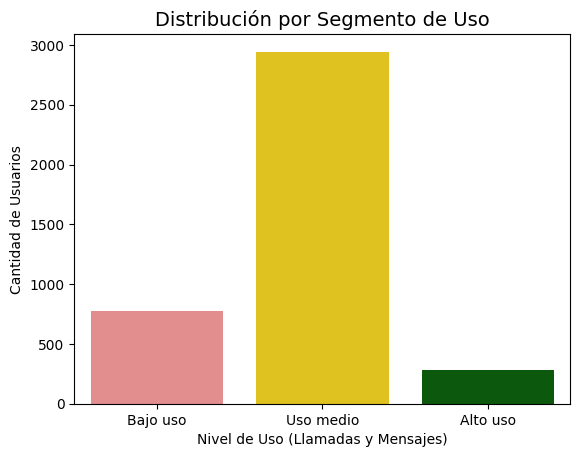

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x= "grupo_uso", order=['Bajo uso', 'Uso medio', 'Alto uso'], palette=["lightcoral", "gold", "darkgreen"])
plt.title('Distribución por Segmento de Uso', fontsize=14)
plt.xlabel('Nivel de Uso (Llamadas y Mensajes)')
plt.ylabel('Cantidad de Usuarios')
plt.show()

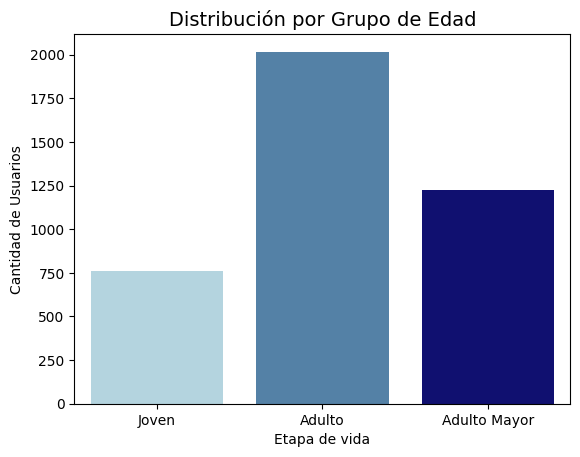

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x= "grupo_edad", order=['Joven', 'Adulto', 'Adulto Mayor'], palette=["lightblue", "steelblue", "navy"])
plt.title('Distribución por Grupo de Edad', fontsize=14)
plt.xlabel('Etapa de vida')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.


###✍️Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- **Outliers de Edad:** Se detectaron registros fuera de rango que debieron ser normalizados para no distorsionar el perfil demográfico.
- **Valores invalidos en city** Se detectó que había entradas con "?", los cuales fueron cambiados a valores nulos para su limpieza
- **Fechas futuras** Los registros son hasta 2024, pero habían registros del 2026 que fueron sustituidos por nulos.


🔍 **Segmentos por Edad**
Se identificaron tres grupos generacionales con comportamientos distintos:
- **Adulto (Mayoritario)**: Es el segmento más grande con más de 2,000 usuarios. Son el motor de ingresos estables y suelen estar en el punto medio de consumo.
- **Adulto Mayor**: Representan un volumen significativo (aprox. 1,250 usuarios). Mayormente ellos contratan el plan Premium.
- **Joven**: El grupo más pequeño (aprox. 750 usuarios), lo que sugiere una oportunidad de penetración de mercado para ConnectaTel mediante ofertas más enfocadas en datos que en minutos.


📊 **Segmentos por Nivel de Uso**
La categorización basada en llamadas y mensajes (<5, <10, >10) reveló:
- **Uso Medio (Dominante)**: Casi 3,000 usuarios se encuentran aquí. Es una base de clientes saludable que utiliza el servicio de forma constante pero moderada.

- **Bajo Uso**: Aproximadamente 800 usuarios están subutilizando su plan. Representan un riesgo de cancelación (churn) si sienten que pagan por algo que no usan.

- **Alto Uso**: Menos de 300 usuarios. Aquí se encuentran los "Heavy Users" y los outliers que superan los 62 minutos mensuales.


➡️ Esto sugiere que La oferta actual de ConnectaTel está "sobredimensionada" para la mayoría (el usuario promedio no llega a consumir ni el 70% de su plan básico), pero es punitiva para el segmento de Alto Uso, quienes rápidamente caen en cobros por excedentes al realizar llamadas largas.


💡 **Recomendaciones**
- **Creación de un plan "Intermedio"**: Diseñar un plan de 300 minutos posicionado entre el Básico y el Premium. Esto capturaría a los usuarios de "Alto Uso" que hoy temen al excedente del Básico pero no quieren pagar el costo del Premium.
- Estrategia de Retención para "Bajo Uso": Implementar una campaña de downgrade asistido o beneficios adicionales para los 800 usuarios de bajo consumo, evitando que cancelen el servicio.
- **Auditoría de Outliers (Uso Comercial)**: Monitorear a los usuarios con llamadas de +150 minutos. Si el patrón es recurrente, deben ser migrados forzosamente a un Plan Corporativo, protegiendo la estabilidad de la red residencial.
- **Enfoque en el Adulto Mayor**: Dado su volumen y su preferencia por la voz, crear un programa de lealtad que premie la fidelidad con descuentos en el Plan Premium, asegurándoles un costo fijo mensual sin importar cuánto hablen.